In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [279]:
df = pd.read_csv('customer_churn.csv')
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [280]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [281]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [282]:
df.isna().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [283]:
df['Churn'] = df['Churn'].replace(2, 1)

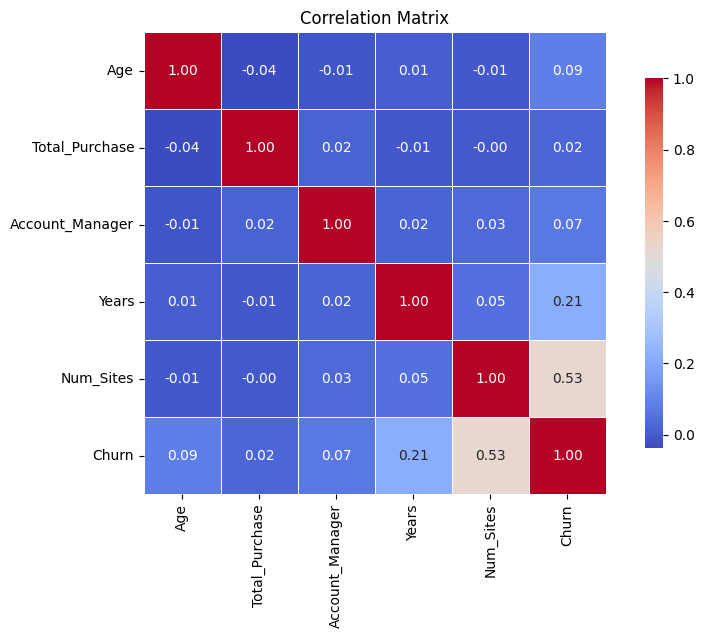

In [284]:
from sklearn.metrics import classification_report, confusion_matrix
df_numerical = df.select_dtypes(include=[np.number])
df_categorical = df.select_dtypes(exclude=[np.number])
corr = df_numerical.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='white')
plt.title('Correlation Matrix')
plt.show()

In [285]:
corr

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
Age,1.000000,-0.037208,-0.014749,0.005625,-0.006070,0.085926
Total_Purchase,-0.037208,1.000000,0.015856,-0.005623,-0.003390,0.024031
Account_Manager,-0.014749,0.015856,1.000000,0.022930,0.033401,0.070611
Years,0.005625,-0.005623,0.022930,1.000000,0.051642,0.214329
Num_Sites,-0.006070,-0.003390,0.033401,0.051642,1.000000,0.525398
Churn,0.085926,0.024031,0.070611,0.214329,0.525398,1.000000


In [286]:
# Ranking the features based on correlation with the target variable
corr_target = corr['Churn'].abs().sort_values(ascending=False)
print(corr_target)

Churn              1.000000
Num_Sites          0.525398
Years              0.214329
Age                0.085926
Account_Manager    0.070611
Total_Purchase     0.024031
Name: Churn, dtype: float64


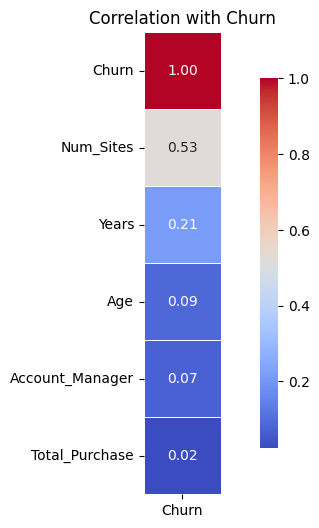

In [287]:
# Visualize the correlation 
plt.figure(figsize=(10, 6))
sns.heatmap(corr_target.to_frame(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='white')
plt.title('Correlation with Churn')
plt.show()

In [288]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


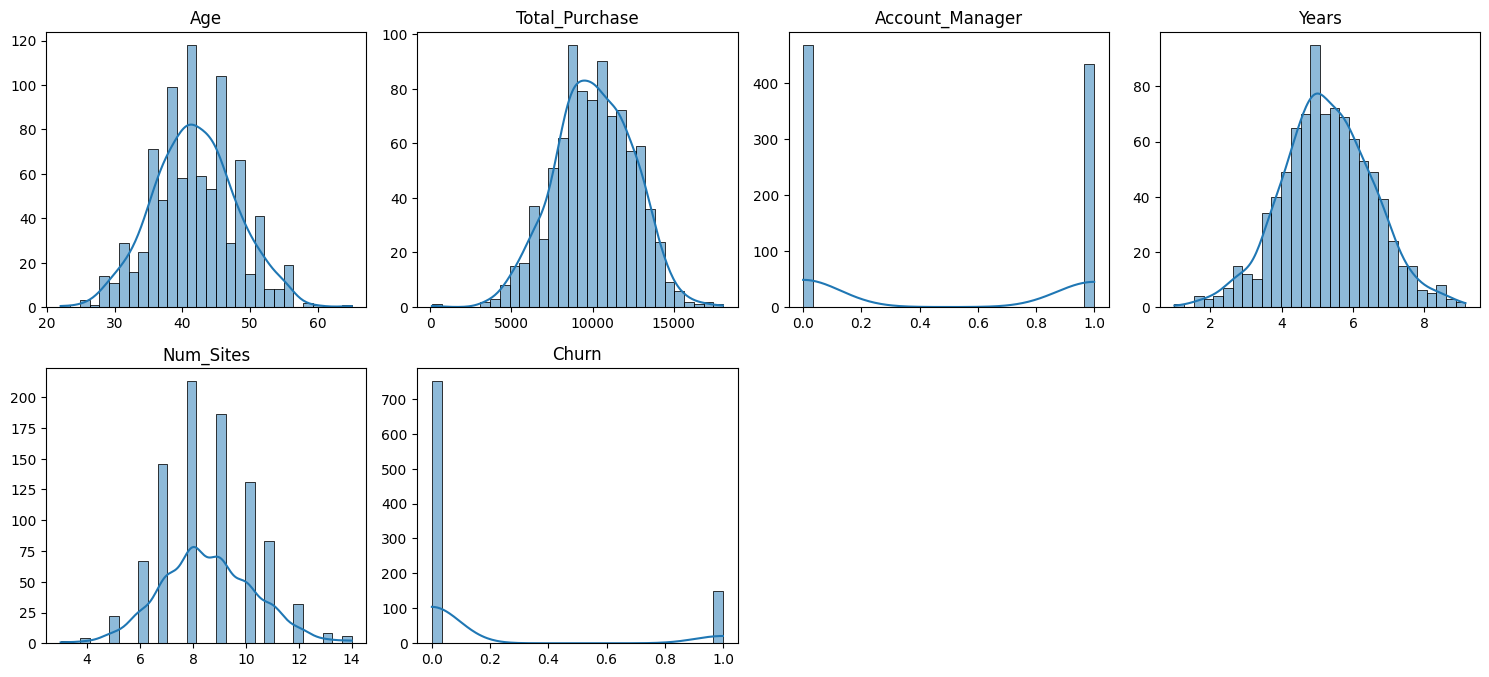

In [289]:
# Visualizing the distribution of numerical features
numerical_features = df_numerical.columns.tolist()
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()

Dropping Irrelevant Features

In [290]:
df = df.drop(['Names', 'Location', 'Company', 'Onboard_date'], axis=1)

In [291]:
df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


In [292]:
df['Churn'].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

In [293]:
df_numerical = df.select_dtypes(include=[np.number])
corr = df_numerical.corr()

In [294]:
print(corr['Churn'].sort_values(ascending=False))

Churn              1.000000
Num_Sites          0.525398
Years              0.214329
Age                0.085926
Account_Manager    0.070611
Total_Purchase     0.024031
Name: Churn, dtype: float64


In [295]:
# Standardizing the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])
df.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,0.029936,0.417054,-0.96291,1.528446,-0.333235,2.236068
1,-0.133352,0.769905,-0.96291,0.963182,1.367585,2.236068
2,-0.623215,1.172234,-0.96291,1.096647,1.934526,2.236068
3,0.029936,-0.852432,-0.96291,1.128051,0.800645,2.236068
4,-0.786503,-0.361917,-0.96291,0.225198,0.233705,2.236068


In [296]:
from sklearn.model_selection import train_test_split
X = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [297]:
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(900, 5) (900,)
(720, 5) (720,)
(180, 5) (180,)


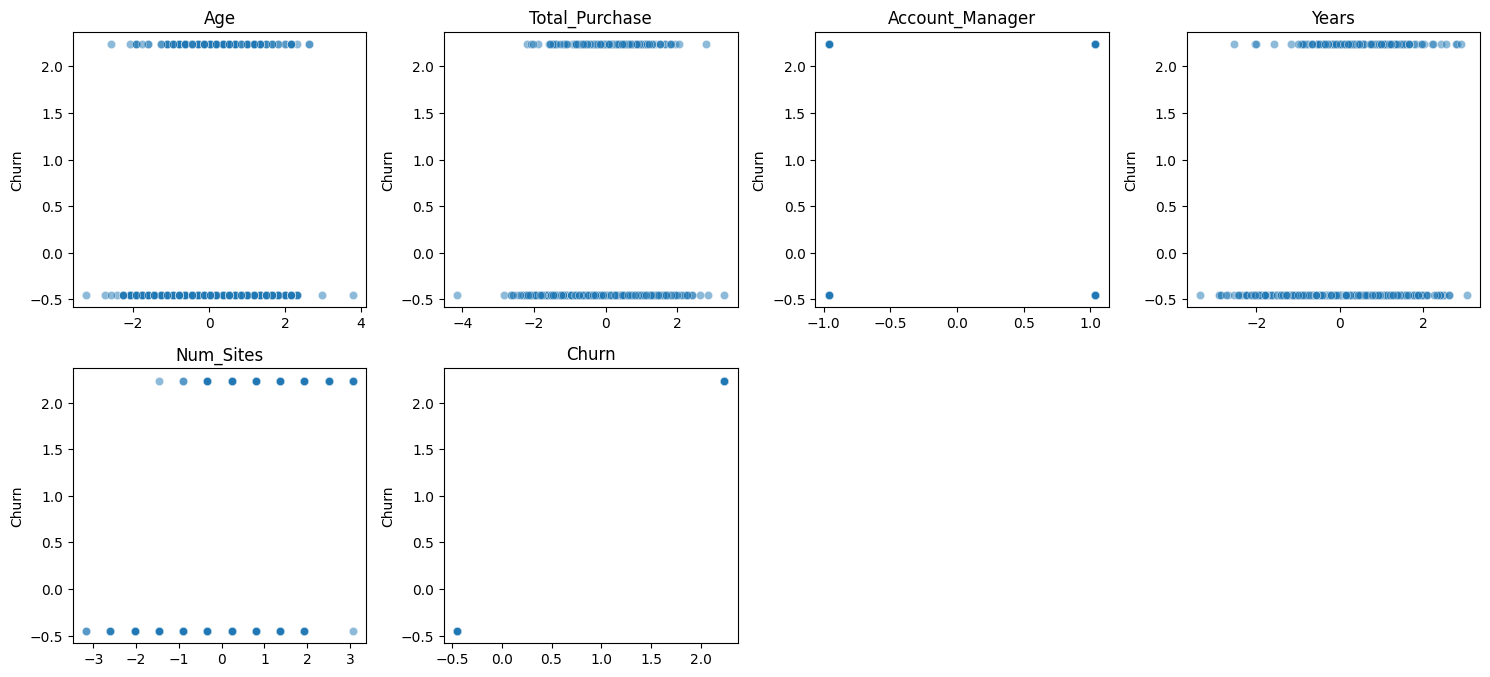

In [298]:
# Scatter plot of numerical features against the target variable
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 4, i + 1)
    sns.scatterplot(x=df[feature], y=df['Churn'], alpha=0.5)
    plt.title(feature)
    plt.xlabel('')
    plt.ylabel('Churn')
plt.tight_layout()

In [299]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [300]:
y_pred = model.predict(X_test)

RandomFOrest Output

In [301]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[144   6]
 [ 18  12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       150
           2       0.67      0.40      0.50        30

    accuracy                           0.87       180
   macro avg       0.78      0.68      0.71       180
weighted avg       0.85      0.87      0.85       180

Accuracy Score: 0.8666666666666667


Logistic Regression Output

In [302]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score 

log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [303]:
y_pred_log = log_model.predict(X_test)
y_pred_proba_log = log_model.predict_proba(X_test)[:, 1]

In [304]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Accuracy Score:", accuracy_score(y_test, y_pred_log))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba_log))
print("Cross-Validation Score:", cross_val_score(log_model, X_train, y_train, cv=5).mean())

Confusion Matrix:


 [[146   4]
 [ 13  17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       150
           2       0.81      0.57      0.67        30

    accuracy                           0.91       180
   macro avg       0.86      0.77      0.81       180
weighted avg       0.90      0.91      0.90       180

Accuracy Score: 0.9055555555555556
ROC AUC Score: 0.9133333333333333
Cross-Validation Score: 0.8861111111111113


Hence, Logistic Regression is the winner here since it gives good accuracy and overall report

In [305]:
df.columns

Index(['Age', 'Total_Purchase', 'Account_Manager', 'Years', 'Num_Sites',
       'Churn'],
      dtype='object')

Churn Prediction for New Customer: 2
Churn Probability for New Customer: 0.61


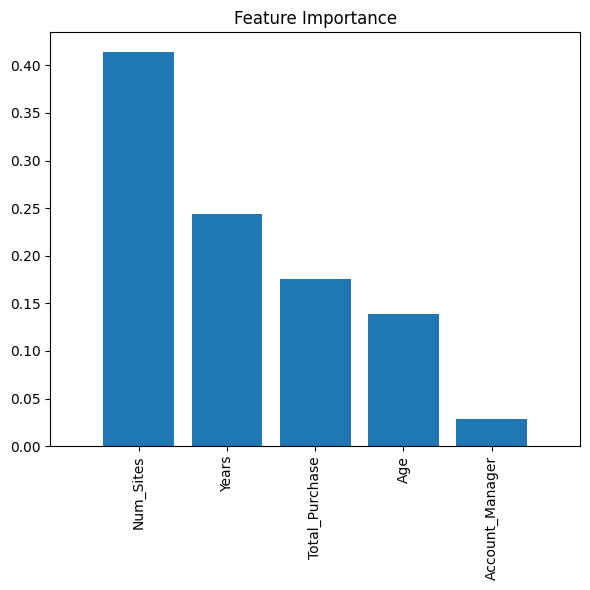

In [306]:
# Testing on dummy data
new_customer = pd.DataFrame([{
    'Age': 45,
    'Total_Purchase': 10000.00,
    'Account_Manager': 1,     # 1 if assigned, 0 if not
    'Years': 5.0,
    'Num_Sites': 8
}])

new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
print("Churn Prediction for New Customer:", prediction[0])
print("Churn Probability for New Customer:", model.predict_proba(new_customer_scaled)[0][1])
# Visualizing feature importance
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(6, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

In [311]:
import joblib
# Save model
joblib.dump(model, 'model.pkl')
# Save scaler (if used for preprocessing)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']